# Example 1.3.10 : Change Point Detection

In [2]:
# example_1310_functions_only.py
# ------------------------------------------------------------
# Example 1.3.10 — piecewise-constant level with change-points
# ------------------------------------------------------------
from typing import Dict, Tuple, Optional
import numpy as np

# ---------------------------
# 0) Helpers
# ---------------------------

def AR_from_C(Ck: int, params: Dict[str, float]) -> Tuple[float, float]:
    if Ck == 0:
        return 1.0, float(params["q0_std"])
    else:
        return 0.0, float(params["R_std"])


# Explanation of the functions 
### 1. `AR_from_C(Ck, params)`

This function encodes the *switching state dynamics* of Example 1.3.10 in the book:

- If **no change** at time $k$ ($C_k = 0$):  
  $A = 1$, $R \approx 0$ (tiny carryover noise for stability).  
  - The code introduces a small noise $q0\_std$ for $C_k=0$ (instead of $R(0)=0$ exactly) to avoid purely deterministic segments (a practical tweak not in the book).  
  - If you set $q0_{std} = 0$, then $𝑊_{𝑘+1}= 𝑊_k$   whenever $C_k=0$.

      → No randomness in those stretches, the state is perfectly flat. This is fine for simulation: you’ll just get piecewise-constant $W_k$. It can be tricky for filtering/smoothing code later, because the state covariance matrix $\Sigma$ may collapse to exactly 0 in flat segments. That can cause: divisions by zero in the Kalman gain, or matrix inversions failing (since variance = 0).


- If **change** at time $k$ ($C_k = 1$):  
  $A = 0$, $R = R_{\text{std}}$ (fresh draw).

This matches the model:
$$
W_{k+1} = A(C_{k+1}) \, W_k + R(C_{k+1}) \, U_k,
\qquad
Y_k = W_k + V_k,
$$
with $A(0) = I$, $R(0) = 0$, $A(1) = 0$, $R(1) = R$ (Example 1.3.10).  

The equivalent formulation,
$$
W_{k+1} =
\begin{cases}
W_k & \text{with prob. } p, \\
U_k & \text{otherwise},
\end{cases}
$$
is Equation **(1.16)** in the book.

---


In [3]:

# ---------------------------
# 1) Simulation
# ---------------------------

def simulate_change_point(n: int, params: Dict[str, float], seed: Optional[int] = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]: #this part with te arrwow can be removed it just shows yoou the expected output.
    """
    Simulate C[0..n-1], W[0..n], Y[0..n-1] where:
      C_k ~ Bernoulli(p),
      W_{k+1} = A(C_k) W_k + R(C_k) U_k,
      Y_k = W_k + S V_k.
    """
    rng = np.random.default_rng(seed)
    p = float(params["p"])
    w0_mean, w0_var = float(params["w0_mean"]), float(params["w0_var"])
    S_std = float(params["S_std"])

    C = rng.binomial(1, p, size=n)
    W = np.empty(n + 1)
    W[0] = rng.normal(w0_mean, np.sqrt(w0_var))
    for k in range(n):
        A_k, R_k = AR_from_C(int(C[k]), params)     # transition k -> k+1
        W[k+1] = A_k * W[k] + R_k * rng.standard_normal()
    Y = W[:-1] + S_std * rng.standard_normal(size=n)
    return C, W, Y




### 2. `simulate_change_point(n, params, seed)`
-  creates the problem: It generates a "ground truth" hidden signal and the noisy observations of it.

This function generates the entire process:

1. **Indicators**  
   $C_k \sim \text{Bernoulli}(p)$ i.i.d., as in Example 1.3.10.

2. **State dynamics**  
   Using the matrices from `AR_from_C`:
  
3. **Observations**  
   $$
   Y_k = W_k + S \, V_k ,
   $$
   with $V_k \sim \mathcal N(0,1)$ and $S = \texttt{S\_std}$.

---
Here we changed a bit the expression of the observation, and added the term $S$. The $S$ lets you control how noisy the observations are. With a larger $S$, $Y_k$ is more “blurred” around $W_k$. With a smaller $S$, $Y_k$ sticks close to $W_k$. The $S$ being different from 1 is just for generalization.

# Algo 5.2.13 of the book 

Be carefull here we changed the notation a bit. The $X$ is here written as $m$, and the $\sigma$ is written as $P$.  Furthermore we introduce prev/ pred which stand for previous and prediction.
 
- solves the problem: It takes only the noisy observations and tries to reconstruct the original hidden signal.

In [4]:

# ----------------------------------------
# 2) Kalman filter (known C) — Alg. 5.2.13
# ----------------------------------------

def kf_known_C(Y: np.ndarray, C: np.ndarray, params: Dict[str, float],
               w0_mean: Optional[float] = None, w0_var: Optional[float] = None
               ) -> Dict[str, np.ndarray]:
    """
    Forward Kalman filter with time-varying (A,R) picked by C.
    Careful with indexing:
      - Observation Y_k depends on W_k.
      - Transition k -> k+1 uses C_k.
      - Prediction for k=0 uses only the prior (no transition applied yet).
    """
    n = len(Y)
    B = 1.0
    S2 = float(params["S_std"]) ** 2
    eps = 1e-12

    m_prev = float(params["w0_mean"]) if w0_mean is None else float(w0_mean) 
    P_prev = float(params["w0_var"])  if w0_var  is None else float(w0_var)

    W_pred  = np.empty(n)  # m_{k|k-1}
    P_pred  = np.empty(n)  # P_{k|k-1}
    W_filt  = np.empty(n)  # m_{k|k}
    P_filt  = np.empty(n)  # P_{k|k}
    innov   = np.empty(n)  # eps_k
    innov_v = np.empty(n)  # Gamma_k
    K_gain  = np.empty(n)  # K_k

    # Store the actual transition A_k, R_k for k -> k+1 (length n)
    A_seq = np.empty(n)
    R_seq = np.empty(n)
    for k in range(n):
        A_seq[k], R_seq[k] = AR_from_C(int(C[k]), params)

    for k in range(n):
        if k == 0:
            # First time step: prediction is just the prior
            m_pred = m_prev
            P_pred_k = P_prev
        else:
            # Use transition (k-1) -> k based on C_{k-1}
            A_prev, R_prev = A_seq[k-1], R_seq[k-1]
            m_pred = A_prev * m_prev
            P_pred_k = A_prev * P_prev * A_prev + R_prev**2

        eps_k = Y[k] - B * m_pred
        Gamma_k = B * P_pred_k * B + S2
        K_k = (P_pred_k * B) / (Gamma_k + eps)

        m_filt = m_pred + K_k * eps_k
        P_filt_k = P_pred_k - K_k * B * P_pred_k

        W_pred[k], P_pred[k] = m_pred, P_pred_k
        W_filt[k], P_filt[k] = m_filt, P_filt_k
        innov[k], innov_v[k] = eps_k, Gamma_k
        K_gain[k] = K_k

        m_prev, P_prev = m_filt, P_filt_k

    return dict(
        W_pred=W_pred, P_pred=P_pred,
        W_filt=W_filt, P_filt=P_filt,
        innov=innov, innov_var=innov_v,
        K=K_gain, A_seq=A_seq, R_seq=R_seq
    )



In [5]:

# ----------------------------------------
# 3) RTS fixed-interval smoother (Alg. 5.2.22)
# ----------------------------------------

def rts_smoother(W_pred: np.ndarray, W_filt: np.ndarray,
                 P_pred: np.ndarray, P_filt: np.ndarray,
                 A_seq: np.ndarray
                 ) -> Tuple[np.ndarray, np.ndarray]:
    """
    Rauch–Tung–Striebel smoother (scalar, time-varying A).
    Uses: J_k = P_{k|k} A_k / P_{k+1|k}, and the standard backward recursions.
    Note: A_seq[k] is the transition from k -> k+1.
    """
    n = len(W_filt)
    W_smooth = np.empty(n)
    P_smooth = np.empty(n)
    eps = 1e-12

    W_smooth[-1] = W_filt[-1]
    P_smooth[-1] = P_filt[-1]
    for k in range(n - 2, -1, -1):
        A_k = A_seq[k]  # transition k -> k+1
        J_k = (P_filt[k] * A_k) / (P_pred[k + 1] + eps)

        W_smooth[k] = W_filt[k] + J_k * (W_smooth[k + 1] - W_pred[k + 1])
        P_smooth[k] = P_filt[k] + J_k * (P_smooth[k + 1] - P_pred[k + 1]) * J_k
    return W_smooth, P_smooth



## Smoothing: Prop. 5.2.21 vs RTS recursion

In the book (CMR, Section 5.2.3):

- The hidden state is denoted $X_k$ (in Example 1.3.10 we call it $W_k$).
- The filter computes conditional means:
  $$
  \hat X_{k|k} = \mathbb{E}[X_k \mid Y_{0:k}], \qquad
  \hat X_{k|k-1} = \mathbb{E}[X_k \mid Y_{0:k-1}],
  $$
  with covariances $\Sigma_{k|k}, \Sigma_{k|k-1}$.

### Proposition 5.2.21
Defines a backward recursion in *information form*:
- Information vector $\kappa_{k|n}$,
- Precision $\Pi_{k|n}$.

Algorithm 5.2.22 uses this to compute smoothed distributions
$(\hat X_{k|n}, \Sigma_{k|n})$.

### RTS form (equivalent)
The same recursion can be written in covariance form using the *smoother gain*:
$$
J_k = \Sigma_{k|k} A_k^\top \Sigma_{k+1|k}^{-1}.
$$

Then the backward recursions become:
$$
\hat X_{k|n} = \hat X_{k|k} + J_k\big(\hat X_{k+1|n} - \hat X_{k+1|k}\big),
$$
$$
\Sigma_{k|n} = \Sigma_{k|k} + J_k\big(\Sigma_{k+1|n} - \Sigma_{k+1|k}\big)J_k^\top.
$$

These are exactly the **Rauch–Tung–Striebel (RTS) smoother** equations.

### Conclusion
- **Prop. 5.2.21 + Alg. 5.2.22** (book) = backward recursion in *information form*.
- **RTS recursion** = equivalent covariance form.
- Both yield the same smoothed means and variances.


In [6]:

# ------------------------------------------------
# 4) FFBS (simulation smoother) to draw W | C, Y
# ------------------------------------------------

def ffbs_sample(W_pred: np.ndarray, W_filt: np.ndarray, P_pred: np.ndarray,
                P_filt: np.ndarray, A_seq: np.ndarray, rng=None
                ) -> np.ndarray:
    """
    Forward-Filter Backward-Sample for a single trajectory {W_k}.
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(W_filt)
    W_s = np.empty(n)
    eps = 1e-12

    W_s[-1] = rng.normal(W_filt[-1], np.sqrt(max(P_filt[-1], 0.0)))
    for k in range(n - 2, -1, -1):
        A_k = A_seq[k]
        J_k = (P_filt[k] * A_k) / (P_pred[k + 1] + eps)
        mean_cond = W_filt[k] + J_k * (W_s[k + 1] - W_pred[k + 1])
        cov_cond  = P_filt[k] - J_k * P_pred[k + 1] * J_k
        cov_cond  = max(cov_cond, 0.0)
        W_s[k] = rng.normal(mean_cond, np.sqrt(cov_cond))
    return W_s


def sample_W_given_C(Y: np.ndarray, C: np.ndarray, params: Dict[str, float], rng=None
                     ) -> np.ndarray:
    """
    One Gibbs block for W | C, Y.
    Draw W_0..W_{n-1} via FFBS, then draw W_n from the last transition using C_{n-1}.
    """
    rng = np.random.default_rng() if rng is None else rng
    out = kf_known_C(Y, C, params)
    W_pred, P_pred = out["W_pred"], out["P_pred"]
    W_filt, P_filt = out["W_filt"], out["P_filt"]
    A_seq, R_seq   = out["A_seq"], out["R_seq"]

    W_draw = ffbs_sample(W_pred, W_filt, P_pred, P_filt, A_seq, rng=rng)

    # Append W_n from transition (n-1 -> n)
    n = len(Y)
    A_last, R_last = A_seq[-1], R_seq[-1]
    Wn = rng.normal(A_last * W_draw[-1], R_last)
    return np.concatenate([W_draw, [Wn]])



In [7]:

# ------------------------------------------------------------
# 5) Gibbs: update C | W  (site-wise Bernoulli with log-scores)
# ------------------------------------------------------------

def _log_norm_pdf(x: float, mean: float, var: float, eps: float = 1e-12) -> float:
    var = max(var, eps)
    return -0.5 * (np.log(2 * np.pi * var) + ((x - mean) ** 2) / var)

def site_logpost_Ck(k: int, W: np.ndarray, params: Dict[str, float], p_change: float
                    ) -> Tuple[float, float]:
    """
    Log posterior scores for C_k in {0,1} using:
      prior: Bernoulli(p_change),
      transition:
         if C_k=0: W_{k+1} ~ N(W_k, q0_std^2),
         if C_k=1: W_{k+1} ~ N(0,    R_std^2).
    """
    w_k, w_k1 = W[k], W[k + 1]
    ll0 = _log_norm_pdf(w_k1, mean=w_k, var=float(params["q0_std"]) ** 2)
    ll1 = _log_norm_pdf(w_k1, mean=0.0, var=float(params["R_std"]) ** 2)
    lp0 = np.log(1.0 - p_change + 1e-15) + ll0
    lp1 = np.log(p_change + 1e-15) + ll1
    return lp0, lp1

def gibbs_change_points(Y: np.ndarray, params: Dict[str, float],
                        n_iter: int = 2000, burn_in: int = 1000, thin: int = 1,
                        init_C: Optional[np.ndarray] = None, rng=None
                        ) -> Dict[str, np.ndarray]:
    """
    Gibbs for (C, W) | Y:
      1) W | C, Y  via KF+FFBS,
      2) C | W, Y  via local Bernoulli updates (using only transition density).
    Returns posterior mean of C and MAP labels.
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(Y)
    p = float(params["p"])

    C = rng.binomial(1, p, size=n) if init_C is None else init_C.astype(int).copy()

    keep = []
    count = np.zeros(n, dtype=float)

    for it in range(n_iter):
        W = sample_W_given_C(Y, C, params, rng=rng)
        for k in range(n):
            lp0, lp1 = site_logpost_Ck(k, W, params, p)
            m = max(lp0, lp1)
            p1 = np.exp(lp1 - m) / (np.exp(lp0 - m) + np.exp(lp1 - m))
            C[k] = rng.binomial(1, p1)

        if it >= burn_in and ((it - burn_in) % thin == 0):
            count += C
            keep.append(C.copy())

    draws = max(len(keep), 1)
    post_prob = count / draws
    C_map = (post_prob >= 0.5).astype(int)
    return dict(post_prob=post_prob, C_map=C_map, samples=np.array(keep))



In [8]:

# ------------------------------------------------------------
# 6) Online change-point detection (particle filter)
# ------------------------------------------------------------

def _systematic_resample(weights: np.ndarray, rng=None) -> np.ndarray:
    """Systematic resampling. Returns ancestor indices."""
    rng = np.random.default_rng() if rng is None else rng
    N = len(weights)
    positions = (rng.random() + np.arange(N)) / N
    cumsum = np.cumsum(weights)
    idx = np.zeros(N, dtype=int)
    i = j = 0
    while i < N:
        if positions[i] < cumsum[j]:
            idx[i] = j; i += 1
        else:
            j += 1
    return idx


In [9]:

def pf_detect(Y: np.ndarray, params: Dict[str, float], N: int = 500,
              lag: int = 0, ess_threshold: float = 0.5, rng=None
              ) -> Dict[str, np.ndarray]:
    """
    Bootstrap particle filter aligned with the model timing:
      - At time k we have W_k; weight by p(Y_k | W_k).
      - (Optionally) resample.
      - Sample C_k ~ Bernoulli(p), store it (for detection),
        and propagate to W_{k+1} using A(C_k), R(C_k).
      - Repeat.

    We report P(C_{k-lag}=1 | Y_{0:k}) using a ring-buffer of the most recent C's.
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(Y)
    p = float(params["p"])
    S2 = float(params["S_std"]) ** 2
    eps = 1e-15

    # Initialize W_0 ~ prior; no C sampled yet
    Wp = rng.normal(float(params["w0_mean"]), np.sqrt(float(params["w0_var"])), size=N)
    w = np.ones(N) / N
    # ring buffer of size lag+1; we fill from right; leftmost is time k-lag
    recent_C = -np.ones((N, lag + 1), dtype=int)

    prob_change_at_lag = np.full(n, np.nan)

    for k in range(n):
        # 1) Weight with current observation Y_k
        ll = -0.5 * (np.log(2 * np.pi * S2) + (Y[k] - Wp)**2 / S2)
        ll -= ll.max()  # stabilize
        w *= np.exp(ll)
        s = w.sum()
        w = (w / s) if s > eps else (np.ones_like(w) / len(w))

        # 2) Report P(C_{k-lag}=1 | Y_{0:k}) if we have it
        if k >= lag and lag >= 0 and recent_C[:, 0].min() >= 0:
            prob_change_at_lag[k] = float((w * (recent_C[:, 0] == 1)).sum())

        # 3) Resample if ESS low
        ess = 1.0 / (w @ w)
        if ess < ess_threshold * len(w):
            idx = _systematic_resample(w, rng)
            Wp = Wp[idx]
            recent_C = recent_C[idx]
            w[:] = 1.0 / len(w)

        # 4) Sample C_k and propagate to W_{k+1}
        Ck = rng.binomial(1, p, size=len(w))

        # shift buffer left, append new C_k to rightmost column
        if lag >= 0:
            if lag > 0:
                recent_C[:, :-1] = recent_C[:, 1:]
            recent_C[:, -1] = Ck

        A_k = np.where(Ck == 0, 1.0, 0.0)
        R_k = np.where(Ck == 0, float(params["q0_std"]), float(params["R_std"]))
        Wp = A_k * Wp + R_k * rng.standard_normal(size=len(w))

    return dict(prob_change_at_lag=prob_change_at_lag)


In [10]:


# ------------------------------------------------------------
# 7) (Optional) quick demo / usage (commented)
# ------------------------------------------------------------
# if __name__ == "__main__":
#     params = {
#         "p": 0.05, "R_std": 2.0, "S_std": 0.5,
#         "w0_mean": 0.0, "w0_var": 25.0, "q0_std": 1e-6
#     }
#     C, W, Y = simulate_change_point(300, params, seed=0)
#     kf = kf_known_C(Y, C, params)
#     W_smooth, P_smooth = rts_smoother(kf["W_pred"], kf["W_filt"], kf["P_pred"], kf["P_filt"], kf["A_seq"])
#     gibbs_out = gibbs_change_points(Y, params, n_iter=1500, burn_in=500, thin=5)
#     pf_out = pf_detect(Y, params, N=300, lag=5)


In [1]:
if __name__ == "__main__":
    import numpy as np
    import matplotlib.pyplot as plt

    # 1) Params + simulate
    params = {
        "p": 0.06,        # change prob
        "R_std": 2.0,     # jump std
        "S_std": 0.5,     # obs noise std
        "w0_mean": 0.0,   # prior mean W0
        "w0_var": 25.0,   # prior var W0
        "q0_std": 1e-6    # tiny drift when no change
    }
    n = 300
    C, W, Y = simulate_change_point(n, params, seed=0)

    # 2) KF + RTS (known C for sanity)
    kf = kf_known_C(Y, C, params)
    W_smooth, P_smooth = rts_smoother(
        kf["W_pred"], kf["W_filt"], kf["P_pred"], kf["P_filt"], kf["A_seq"]
    )

    t = np.arange(n)

    # FIGURE 1 — Data + estimates
    plt.figure(figsize=(10,4))
    plt.plot(t, Y, ".", ms=3, label="Y (observed)")
    plt.plot(t, W[:-1], "-", lw=1, label="True W")
    plt.plot(t, kf["W_filt"], "-", lw=1, label="KF filtered")
    plt.plot(t, W_smooth, "-", lw=2, label="RTS smoothed")
    plt.title("Example 1.3.10 — Observations and Estimates")
    plt.xlabel("time k"); plt.legend(); plt.tight_layout()

    # 3) Optional: Gibbs and PF quick demos (comment out if you only want 1 plot)
    g = gibbs_change_points(Y, params, n_iter=800, burn_in=300, thin=5)  # small, fast
    pf = pf_detect(Y, params, N=300, lag=5)

    # FIGURE 2 — Change-points
    plt.figure(figsize=(10,3))
    plt.step(t, C, where="post", label="True C (jump=1)", lw=1)
    plt.plot(t, g["post_prob"], label="Gibbs P(C=1|Y)", lw=1)
    plt.plot(t, pf["prob_change_at_lag"], label="PF P(C_{k-5}=1|Y_{0:k})", lw=1)
    plt.ylim(-0.1, 1.1)
    plt.title("Change-point probabilities")
    plt.xlabel("time k"); plt.legend(); plt.tight_layout()

    # >>> IMPORTANT: actually show the figures
    plt.show()


NameError: name 'simulate_change_point' is not defined

RMSE(filtered): 0.240
RMSE(smoothed): 0.137
z-scores mean=0.082, std=0.923 (target: ~0, ~1)


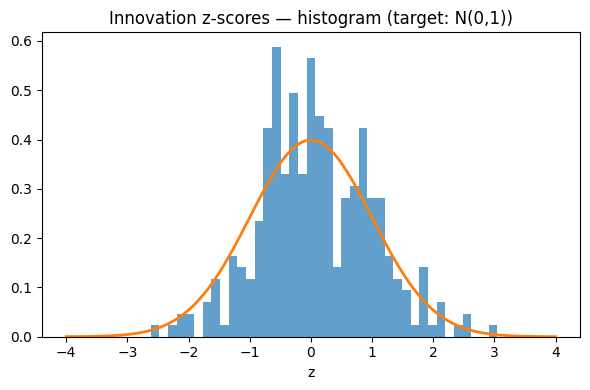

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a - b)**2)))

# 1) RMSE: filtered vs true, smoothed vs true  (expect: smooth < filtered)
rmse_filt   = rmse(kf["W_filt"],   W[:-1])
rmse_smooth = rmse(W_smooth,       W[:-1])
print(f"RMSE(filtered): {rmse_filt:.3f}")
print(f"RMSE(smoothed): {rmse_smooth:.3f}")

# 2) Innovation z-scores: z_k ~ N(0,1) if S is well tuned
z = kf["innov"] / np.sqrt(kf["innov_var"])
z_mean, z_std = float(np.mean(z)), float(np.std(z))
print(f"z-scores mean={z_mean:.3f}, std={z_std:.3f} (target: ~0, ~1)")

# 2a) z-score time series with +/-3 bands
#plt.figure(figsize=(10,3))
#plt.plot(t, z, lw=0.8)
#plt.axhline(0,  lw=1)
#plt.axhline(3,  lw=1, linestyle="--")
#plt.axhline(-3, lw=1, linestyle="--")
#plt.title("Innovation z-scores  $z_k = \\varepsilon_k/\\sqrt{\\Gamma_k}$")
#plt.xlabel("time k")
#plt.tight_layout()

# 2b) z-score histogram with N(0,1) overlay
xs = np.linspace(-4, 4, 200)
norm_pdf = 1/np.sqrt(2*np.pi) * np.exp(-0.5*xs**2)
plt.figure(figsize=(6,4))
plt.hist(z, bins=40, density=True, alpha=0.7)
plt.plot(xs, norm_pdf, lw=2)
plt.title("Innovation z-scores — histogram (target: N(0,1))")
plt.xlabel("z"); plt.tight_layout()
